In [ ]:
# Instalación de bibliotecas
!pip -q install amplpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 31.2 MB/s eta 0:00:00


In [ ]:
# 1. Instalación e inicialización de AMPL con tu licencia Community Edition
from amplpy import ampl_notebook

# Inicializa AMPL en Colab con tu UUID (Community Edition) Inicializar AMPL
ampl = ampl_notebook(
    modules=["highs", "cbc", "gurobi", "cplex"],  # solvers disponibles
    license_uuid="936b618d-a013-406f-9809-49679f557c26"
)

Licensed to AMPL Academic Community Edition License for <m.godoyseplveda@uandresbello.edu>.


In [ ]:
%%writefile 3_2_3.mod
# Modelo para el ejercicio 3.2-3

param cash;   # dinero disponible
param hours;  # horas disponibles

param c1;     # costo inversion E1
param h1;     # horas inversion E1
param g1;     # ganancia inversion E1

param c2;
param h2;
param g2;

var x1 >= 0 <= 1;
var x2 >= 0 <= 1;

maximize Z: g1 * x1 + g2 * x2;

s.t. Dinero: c1 * x1 + c2 * x2 <= cash;
s.t. Tiempo: h1 * x1 + h2 * x2 <= hours;


Writing 3_2_3.mod


In [ ]:
%%writefile 3_2_3.dat
param cash := 6000;
param hours := 600;

param c1 := 5000;
param h1 := 400;
param g1 := 4500;

param c2 := 4000;
param h2 := 500;
param g2 := 4500;


Writing 3_2_3.dat


In [ ]:
from amplpy import AMPL
ampl = AMPL()

ampl.read("3_2_3.mod")
ampl.read_data("3_2_3.dat")
ampl.option['solver'] = 'highs'
ampl.solve()
ampl.display("x1", "x2", "Z")


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 6000
2 simplex iterations
0 barrier iterations
x1 = 0.666667
x2 = 0.666667
Z = 6000



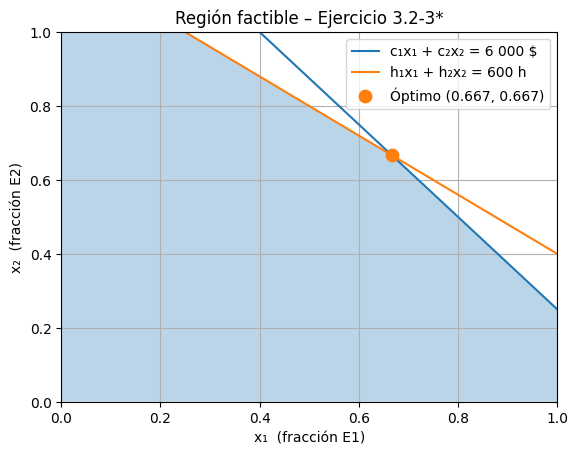

In [ ]:
import numpy as np, matplotlib.pyplot as plt

x1 = np.linspace(0, 1, 400)
x2_money = (6000 - 5000*x1) / 4000          # c₁x₁ + c₂x₂ = 6000
x2_time  = ( 600 -  400*x1) /  500          # h₁x₁ + h₂x₂ =  600
x2_feas  = np.minimum(x2_money, x2_time)
x2_feas  = np.clip(x2_feas, 0, 1)           # 0 ≤ x₂ ≤ 1

plt.figure()
plt.plot(x1, x2_money, label='c₁x₁ + c₂x₂ = 6 000 $')
plt.plot(x1, x2_time,  label='h₁x₁ + h₂x₂ = 600 h')
plt.fill_between(x1, 0, x2_feas, alpha=.3)
plt.scatter(2/3, 2/3, s=80,
            label='Óptimo (0.667, 0.667)', zorder=5)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel('x₁  (fracción E1)'); plt.ylabel('x₂  (fracción E2)')
plt.title('Región factible – Ejercicio 3.2-3*')
plt.grid(); plt.legend(); plt.show()
